# Feature selection

## Setup

### Imports and functions

In [33]:
import pandas as pd
import glob #For combining individual files into one dataframe
from pathlib import Path
import matplotlib.pyplot as plt

In [34]:
def plot_voyage_on_coastline(voyage_data, coastline_data, padding=0.05) -> None:
    """
    Function to plot a voyage's trajectory on a coastline map.

    Args:
        voyage_data: DataFrame containing voyage data, including latitude, longitude, and timestamps.
        coastline_data: GeoDataFrame containing coastline data in GeoPandas format.
        padding: Float padding around the trajectory for zooming.
    """
    
    # Ensure the data is sorted by timestamp
    voyage_data = voyage_data.sort_values(by="pos_timestamp", ascending=True, inplace=False)

    # Get min/max latitudes and longitudes from the voyage data to define the zoom area
    min_lon, max_lon = voyage_data.longitude.min(), voyage_data.longitude.max()
    min_lat, max_lat = voyage_data.latitude.min(), voyage_data.latitude.max()

    # Add some padding to the zoom area
    xlim = (min_lon - padding, max_lon + padding)
    ylim = (min_lat - padding, max_lat + padding)

    # Create the plot
    _, ax = plt.subplots(figsize=(10, 6))

    # Plot the coastline
    coastline_data.plot(ax=ax, color='black', linewidth=0.8, label="Coastline")

    # Plot the vessel trajectory
    ax.plot(voyage_data.longitude, voyage_data.latitude, marker='o', linestyle='-', color='b', label="Voyage Trajectory")

    # Set axis limits for zooming in
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    # Labels and title
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title("Voyage Trajectory on Coastline Map")

    # Show legend and grid
    ax.legend()
    ax.grid()

    # Show the plot
    plt.show()

In [35]:
def load_parquet(path_pattern: str, engine='fastparquet') -> pd.DataFrame:
    """
    Loads parquet file(s).
    Supports glob patterns like "*.parquet.gzip".
    
    Args:
        path_pattern: File path or glob pattern.
        engine: Parquet engine.

    Returns:
        Single DataFrame, concatenated if multiple files.
    """

    files = glob.glob(path_pattern)
    if not files:
        raise FileNotFoundError(f"No files found matching: {path_pattern}")
    
    dfs = [pd.read_parquet(f, engine=engine) for f in files]
    df = pd.concat(dfs, ignore_index=True) if len(dfs) > 1 else dfs[0]
    print(f"Loaded {len(df):,} rows from {len(dfs)} files matching \"{path_pattern}\"")
    
    return df

## Load coastline map

<Axes: >

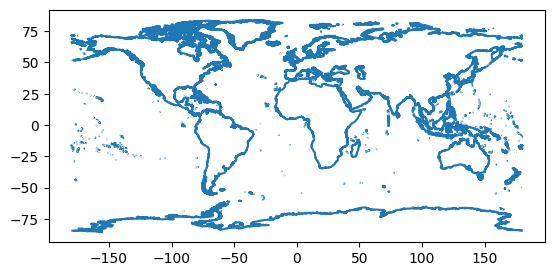

In [36]:
# Load coastline map data from Natural Earth 
import geopandas as gpd
coastline = gpd.read_file("./data/ne_10m_coastline/ne_10m_coastline.shp")
coastline.plot()

## Load AIS data and voyage META data
We're only interested in arrivals to Valencia, as it's there we aim to optimize berth allocation and scheduling, thus we can forego departures.

In [37]:
arrivals_ais_data = load_parquet("./data/mission-voyage-examples/ESVLC-arrivals-voyage-ais-data-*.parquet.gzip")
arrivals_ais_meta_data = load_parquet("./data/mission-voyage-examples/ESVLC-arrivals-voyage-metadata-*.parquet.gzip")

Loaded 3,311,442 rows from 12 files matching "./data/mission-voyage-examples/ESVLC-arrivals-voyage-ais-data-*.parquet.gzip"
Loaded 43,352 rows from 12 files matching "./data/mission-voyage-examples/ESVLC-arrivals-voyage-metadata-*.parquet.gzip"


### Inspect AIS data

In [38]:
arrivals_ais_data.shape

(3311442, 50)

In [39]:
arrivals_ais_data.columns

Index(['voyage_id', 'voyage_status', 'mmsi', 'pos_timestamp',
       'navigation_status', 'position_accuracy', 'longitude', 'latitude',
       'course_over_ground', 'true_heading', 'timestamp_seconds', 'raim',
       'rate_of_turn', 'speed_over_ground', 'pos_source', 'call_sign', 'name',
       'ship_type', 'ref_point_a', 'ref_point_b', 'ref_point_c', 'ref_point_d',
       'position_device', 'eta', 'draught', 'destination', 'meta_timestamp',
       'imo', 'meta_source', 'flag', 'build_year', 'length', 'width',
       'capacity_dwt', 'manager', 'owner', 'builder', 'class_society',
       'capacity_gt', 'capacity_teu', 'capacity_liquid_gas',
       'capacity_passenger', 'capacity_liquid_oil', 'commercial_size_class',
       'vessel_type_details', 'draught_max', 'draught_min', 'capacity_nt',
       'vid_prefix', 'month'],
      dtype='object')

In [40]:
arrivals_ais_data.head()

,voyage_id,voyage_status,mmsi,pos_timestamp,navigation_status,position_accuracy,longitude,latitude,course_over_ground,true_heading,...,capacity_liquid_gas,capacity_passenger,capacity_liquid_oil,commercial_size_class,vessel_type_details,draught_max,draught_min,capacity_nt,vid_prefix,month
0,00924e48-65ea-4ec5-85bc-d97828d10df4,PENDING_DEPARTURE,224185730,2024-01-01 05:11:09,UNDEFINED,False,-0.330460,39.426970,360.000000,511,...,0,0,0,,,0.0,0.0,0,00,2024-01
1,00924e48-65ea-4ec5-85bc-d97828d10df4,PENDING_DEPARTURE,224185730,2024-01-01 05:29:09,UNDEFINED,False,-0.330560,39.426960,360.000000,511,...,0,0,0,,,0.0,0.0,0,00,2024-01
2,00924e48-65ea-4ec5-85bc-d97828d10df4,PENDING_DEPARTURE,224185730,2024-01-01 05:50:10,UNDEFINED,False,-0.330510,39.426940,360.000000,511,...,0,0,0,,,0.0,0.0,0,00,2024-01
3,0194e307-841e-4b36-85e6-4eec645c9d0a,STOPPED,636015990,2024-01-01 05:00:22,AT_ANCHOR,True,-0.257450,39.395163,236.899994,241,...,0,0,0,HANDYSIZE,Bulk Carrier,10.6,4.8,10500,01,2024-01
4,0194e307-841e-4b36-85e6-4eec645c9d0a,STOPPED,636015990,2024-01-01 05:15:22,AT_ANCHOR,True,-0.257393,39.395095,194.899994,242,...,0,0,0,HANDYSIZE,Bulk Carrier,10.6,4.8,10500,01,2024-01


### Inspect voyage META data

In [41]:
arrivals_ais_meta_data.shape

(43352, 17)

In [42]:
arrivals_ais_meta_data.columns

Index(['voyage_id', 'mmsi', 'departure_time', 'departure_locode',
       'departure_latitude', 'departure_longitude', 'arrival_time',
       'arrival_locode', 'arrival_latitude', 'arrival_longitude',
       'prev_voyage_id', 'next_voyage_id', 'departed_port_call_id',
       'arrived_port_call_id', 'duration', 'arrival_country', 'arrival_date'],
      dtype='object')

In [43]:
arrivals_ais_meta_data.head()

,voyage_id,mmsi,departure_time,departure_locode,departure_latitude,departure_longitude,arrival_time,arrival_locode,arrival_latitude,arrival_longitude,prev_voyage_id,next_voyage_id,departed_port_call_id,arrived_port_call_id,duration,arrival_country,arrival_date
0,f4a7d707-95c8-4e3f-93f4-c6000e57853a,224208000,2024-01-15 22:57:24,ESVLC,39.441430,-0.317925,2024-01-15 23:58:36,ESVLC,39.442105,-0.317382,f49ebf4b-71a0-4c81-8317-59d5930c79ed,864c813c-e3d1-4627-9088-750d4bcb9f96,,,3672.0,ES,2024-01-16
1,597c19e1-449b-49a3-9044-62788862926a,225952430,2024-01-15 22:54:55,ESVLC,39.421110,-0.329000,2024-01-16 00:00:00,ESVLC,39.424800,-0.327170,b228aff6-44bb-479c-8cef-ea39fd47b4f0,f01811e2-e6ce-49e6-8877-60d7b326d46e,,,3905.0,ES,2024-01-16
2,ec23c291-f150-4314-a4b7-5834e47c7f7a,255915587,2024-01-15 22:22:37,ESVLC,39.394322,-0.275112,2024-01-16 00:33:06,ESVLC,39.434488,-0.327693,776e4362-e3f9-47ea-97d4-df89891f1204,03f0aad7-0ec9-4f83-a8d4-335b75906a29,,,7829.0,ES,2024-01-16
3,98074eeb-fe2a-4478-8e51-8c9ea2aed4f6,205345130,2024-01-15 22:53:39,ESVLC,39.430230,-0.332620,2024-01-16 00:29:40,ESVLC,39.430240,-0.332640,2737f7cd-015c-45bc-9bd4-d0f2134b917c,e20b07a6-59b9-47f0-92af-c91892a34149,,,5761.0,ES,2024-01-16
4,4c617e21-5ff2-423e-9c81-d4e3b61986dd,255806500,2024-01-15 11:17:21,ESBCN,41.310288,2.150347,2024-01-16 00:39:26,ESVLC,39.439080,-0.325422,115375ca-6147-4c60-910f-13ef7da40f06,2d6446e8-b61b-4da4-aefe-9d949aaac8ec,,,48125.0,ES,2024-01-16


#### Check if the voyage META data contains any duplicates

In [ ]:
dupe_mask = arrivals_ais_meta_data["voyage_id"].duplicated(keep="first")
dupes = arrivals_ais_meta_data[dupe_mask].copy()

print(f"Duplicated rows: {len(dupes)}")

if (len(dupes)):
    dupes.head()

Duplicated rows: 0


### Merging AIS data with voyage META data
The AIS data is the dynamic, continuously transmitted AIS data samples from vessels, whereas the META data represents the static information of the voyage.
This means the META data includes e.g. the duration of the voyage, i.e. our truth values for supervised ML.
Thus we merge them into a single DataFrame.

In [45]:
ais_meta_merged = arrivals_ais_data.merge(
    arrivals_ais_meta_data,
    on="voyage_id",
    how="left",
    suffixes=("_ais", "_meta"),
)

#### Check how many AIS data samples have voyage META data

In [46]:
has_meta_pct = ais_meta_merged["arrival_time"].notna().mean() * 100
print(f"{has_meta_pct:.2f}% of AIS data samples have metadata")

100.00% of AIS data samples have metadata


In [47]:
ais_meta_merged.shape

(3311442, 66)

In [48]:
ais_meta_merged.columns

Index(['voyage_id', 'voyage_status', 'mmsi_ais', 'pos_timestamp',
       'navigation_status', 'position_accuracy', 'longitude', 'latitude',
       'course_over_ground', 'true_heading', 'timestamp_seconds', 'raim',
       'rate_of_turn', 'speed_over_ground', 'pos_source', 'call_sign', 'name',
       'ship_type', 'ref_point_a', 'ref_point_b', 'ref_point_c', 'ref_point_d',
       'position_device', 'eta', 'draught', 'destination', 'meta_timestamp',
       'imo', 'meta_source', 'flag', 'build_year', 'length', 'width',
       'capacity_dwt', 'manager', 'owner', 'builder', 'class_society',
       'capacity_gt', 'capacity_teu', 'capacity_liquid_gas',
       'capacity_passenger', 'capacity_liquid_oil', 'commercial_size_class',
       'vessel_type_details', 'draught_max', 'draught_min', 'capacity_nt',
       'vid_prefix', 'month', 'mmsi_meta', 'departure_time',
       'departure_locode', 'departure_latitude', 'departure_longitude',
       'arrival_time', 'arrival_locode', 'arrival_latitude',
  

In [49]:
ais_meta_merged.head()

,voyage_id,voyage_status,mmsi_ais,pos_timestamp,navigation_status,position_accuracy,longitude,latitude,course_over_ground,true_heading,...,arrival_locode,arrival_latitude,arrival_longitude,prev_voyage_id,next_voyage_id,departed_port_call_id,arrived_port_call_id,duration,arrival_country,arrival_date
0,00924e48-65ea-4ec5-85bc-d97828d10df4,PENDING_DEPARTURE,224185730,2024-01-01 05:11:09,UNDEFINED,False,-0.330460,39.426970,360.000000,511,...,ESVLC,39.426980,-0.33052,fe242117-538c-4d82-bb4a-4195d8290a6b,041bbc52-764f-47cc-9322-b6472389860c,,,4253.0,ES,2024-01-01
1,00924e48-65ea-4ec5-85bc-d97828d10df4,PENDING_DEPARTURE,224185730,2024-01-01 05:29:09,UNDEFINED,False,-0.330560,39.426960,360.000000,511,...,ESVLC,39.426980,-0.33052,fe242117-538c-4d82-bb4a-4195d8290a6b,041bbc52-764f-47cc-9322-b6472389860c,,,4253.0,ES,2024-01-01
2,00924e48-65ea-4ec5-85bc-d97828d10df4,PENDING_DEPARTURE,224185730,2024-01-01 05:50:10,UNDEFINED,False,-0.330510,39.426940,360.000000,511,...,ESVLC,39.426980,-0.33052,fe242117-538c-4d82-bb4a-4195d8290a6b,041bbc52-764f-47cc-9322-b6472389860c,,,4253.0,ES,2024-01-01
3,0194e307-841e-4b36-85e6-4eec645c9d0a,STOPPED,636015990,2024-01-01 05:00:22,AT_ANCHOR,True,-0.257450,39.395163,236.899994,241,...,ESVLC,39.445885,-0.32386,bef4acd3-5a88-43e4-8f86-9309712c23a3,6bb42933-b678-4cea-a316-00d41e32127b,,,265375.0,ES,2024-01-01
4,0194e307-841e-4b36-85e6-4eec645c9d0a,STOPPED,636015990,2024-01-01 05:15:22,AT_ANCHOR,True,-0.257393,39.395095,194.899994,242,...,ESVLC,39.445885,-0.32386,bef4acd3-5a88-43e4-8f86-9309712c23a3,6bb42933-b678-4cea-a316-00d41e32127b,,,265375.0,ES,2024-01-01


### Check if mmsi_ais and mmsi_meta are equal
If so, drop mmsi_meta column and rename mmsi_ais to mmsi

In [50]:
same_mmsi_mask = ais_meta_merged["mmsi_ais"] == ais_meta_merged["mmsi_meta"]
pct_same = same_mmsi_mask.mean() * 100
print(f"mmsi_ais and mmsi_meta match in {pct_same:.2f}% of merged rows")


mmsi_ais and mmsi_meta match in 100.00% of merged rows


In [51]:
ais_meta_merged = ais_meta_merged.drop("mmsi_meta", axis="columns")
ais_meta_merged.columns

Index(['voyage_id', 'voyage_status', 'mmsi_ais', 'pos_timestamp',
       'navigation_status', 'position_accuracy', 'longitude', 'latitude',
       'course_over_ground', 'true_heading', 'timestamp_seconds', 'raim',
       'rate_of_turn', 'speed_over_ground', 'pos_source', 'call_sign', 'name',
       'ship_type', 'ref_point_a', 'ref_point_b', 'ref_point_c', 'ref_point_d',
       'position_device', 'eta', 'draught', 'destination', 'meta_timestamp',
       'imo', 'meta_source', 'flag', 'build_year', 'length', 'width',
       'capacity_dwt', 'manager', 'owner', 'builder', 'class_society',
       'capacity_gt', 'capacity_teu', 'capacity_liquid_gas',
       'capacity_passenger', 'capacity_liquid_oil', 'commercial_size_class',
       'vessel_type_details', 'draught_max', 'draught_min', 'capacity_nt',
       'vid_prefix', 'month', 'departure_time', 'departure_locode',
       'departure_latitude', 'departure_longitude', 'arrival_time',
       'arrival_locode', 'arrival_latitude', 'arrival_longit

In [52]:
ais_meta_merged.rename(columns={"mmsi_ais": "mmsi"}, inplace=True)

In [71]:
ais_meta_merged.columns

Index(['voyage_id', 'voyage_status', 'mmsi', 'pos_timestamp',
       'navigation_status', 'position_accuracy', 'longitude', 'latitude',
       'course_over_ground', 'true_heading', 'timestamp_seconds', 'raim',
       'rate_of_turn', 'speed_over_ground', 'pos_source', 'call_sign', 'name',
       'ship_type', 'ref_point_a', 'ref_point_b', 'ref_point_c', 'ref_point_d',
       'position_device', 'eta', 'draught', 'destination', 'meta_timestamp',
       'imo', 'meta_source', 'flag', 'build_year', 'length', 'width',
       'capacity_dwt', 'manager', 'owner', 'builder', 'class_society',
       'capacity_gt', 'capacity_teu', 'capacity_liquid_gas',
       'capacity_passenger', 'capacity_liquid_oil', 'commercial_size_class',
       'vessel_type_details', 'draught_max', 'draught_min', 'capacity_nt',
       'vid_prefix', 'month', 'departure_time', 'departure_locode',
       'departure_latitude', 'departure_longitude', 'arrival_time',
       'arrival_locode', 'arrival_latitude', 'arrival_longitude'

## Pre-processing

### Defining population

#### Filter out non-commercial vessels

In [54]:
ais_meta_merged["vessel_type_details"].unique()

array(['', 'Bulk Carrier', 'General Dry Cargo', 'Chemical Tanker',
       'Container Ship', 'Offshore', 'Tanker', 'Roll-on Roll-off',
       'Vehicle/Passenger', 'Pure Car Carrier', 'Miscellaneous',
       'Passenger Ship', 'LPG Carrier'], dtype=object)

In [55]:
ais_meta_merged["vessel_type_details"].value_counts(normalize=True).mul(100).round(2)

vessel_type_details
                     64.83
Container Ship       23.16
Roll-on Roll-off      2.51
Chemical Tanker       2.12
Tanker                1.91
General Dry Cargo     1.32
Pure Car Carrier      1.32
Bulk Carrier          1.26
Offshore              1.22
Vehicle/Passenger     0.24
Passenger Ship        0.06
Miscellaneous         0.05
LPG Carrier           0.01
Name: proportion, dtype: float64

In [56]:
VALID_VESSEL_TYPES = ["Bulk Carrier", "General Dry Cargo", "Chemical Tanker", "Container Ship", "Tanker", "LPG Carrier", "Pure Car Carrier", "Roll-on Roll-off"]

mask = ais_meta_merged["vessel_type_details"].isin(VALID_VESSEL_TYPES)
cargo_ais_meta_merged = ais_meta_merged[mask].copy()
cargo_ais_meta_merged.head()

,voyage_id,voyage_status,mmsi,pos_timestamp,navigation_status,position_accuracy,longitude,latitude,course_over_ground,true_heading,...,arrival_locode,arrival_latitude,arrival_longitude,prev_voyage_id,next_voyage_id,departed_port_call_id,arrived_port_call_id,duration,arrival_country,arrival_date
3,0194e307-841e-4b36-85e6-4eec645c9d0a,STOPPED,636015990,2024-01-01 05:00:22,AT_ANCHOR,True,-0.257450,39.395163,236.899994,241,...,ESVLC,39.445885,-0.323860,bef4acd3-5a88-43e4-8f86-9309712c23a3,6bb42933-b678-4cea-a316-00d41e32127b,,,265375.0,ES,2024-01-01
4,0194e307-841e-4b36-85e6-4eec645c9d0a,STOPPED,636015990,2024-01-01 05:15:22,AT_ANCHOR,True,-0.257393,39.395095,194.899994,242,...,ESVLC,39.445885,-0.323860,bef4acd3-5a88-43e4-8f86-9309712c23a3,6bb42933-b678-4cea-a316-00d41e32127b,,,265375.0,ES,2024-01-01
5,0194e307-841e-4b36-85e6-4eec645c9d0a,STOPPED,636015990,2024-01-01 05:33:22,AT_ANCHOR,True,-0.257378,39.395087,242.300003,244,...,ESVLC,39.445885,-0.323860,bef4acd3-5a88-43e4-8f86-9309712c23a3,6bb42933-b678-4cea-a316-00d41e32127b,,,265375.0,ES,2024-01-01
6,0194e307-841e-4b36-85e6-4eec645c9d0a,STOPPED,636015990,2024-01-01 05:48:22,AT_ANCHOR,True,-0.257395,39.395017,250.000000,248,...,ESVLC,39.445885,-0.323860,bef4acd3-5a88-43e4-8f86-9309712c23a3,6bb42933-b678-4cea-a316-00d41e32127b,,,265375.0,ES,2024-01-01
10,01f80139-2bd0-4ff0-8cdd-33c0064ba220,PENDING_DEPARTURE,577005000,2024-01-29 21:02:50,MOORED,False,-0.321315,39.445050,178.199997,111,...,ESVLC,39.445048,-0.321325,10b4dad4-687a-48c3-ad7d-0d79adea92e7,a6910090-2954-47dc-89ad-22f0139013d7,,,3611.0,ES,2024-01-31


#### Filter out voyages with invalid voyage status

In [57]:
cargo_ais_meta_merged["voyage_status"].unique()

array(['STOPPED', 'PENDING_DEPARTURE', 'UNDER_WAY', 'COMPLETED'],
      dtype=object)

In [58]:
cargo_ais_meta_merged["voyage_status"].value_counts(normalize=True).mul(100).round(2)

voyage_status
UNDER_WAY            51.19
PENDING_DEPARTURE    32.44
STOPPED              15.63
COMPLETED             0.74
Name: proportion, dtype: float64

In [59]:
VALID_VOYAGE_STATUSES = ["UNDER_WAY"]

mask = cargo_ais_meta_merged["voyage_status"].isin(VALID_VOYAGE_STATUSES)
cargo_ais_meta_merged = cargo_ais_meta_merged[mask].copy()
cargo_ais_meta_merged.head()

,voyage_id,voyage_status,mmsi,pos_timestamp,navigation_status,position_accuracy,longitude,latitude,course_over_ground,true_heading,...,arrival_locode,arrival_latitude,arrival_longitude,prev_voyage_id,next_voyage_id,departed_port_call_id,arrived_port_call_id,duration,arrival_country,arrival_date
22,029a4b25-666a-41dd-ad98-f3dd0b467c92,UNDER_WAY,620331000,2024-01-01 05:48:00,UNDER_WAY_USING_ENGINES,True,3.033163,38.986765,277.799988,274,...,ESVLC,39.444928,-0.320740,26d91f33-f8bb-4ea2-8a89-50cefa59059c,a314bc7a-6bfb-4968-9e93-fec84a4bffa6,,,664483.0,ES,2024-01-03
84,013e0856-21cb-4def-81b4-bd9d1e3fed1b,UNDER_WAY,249930000,2024-01-25 23:03:11,UNDER_WAY_USING_ENGINES,False,-0.197270,39.508602,219.399994,219,...,ESVLC,39.448730,-0.321843,58d551e1-5fb2-4d1a-9399-39e313538bfa,47e946fc-fc1a-4e9c-bc9f-8fd8fba3b6f2,,,19079.0,ES,2024-01-26
85,013e0856-21cb-4def-81b4-bd9d1e3fed1b,UNDER_WAY,249930000,2024-01-25 23:19:31,UNDER_WAY_USING_ENGINES,False,-0.227538,39.479712,221.899994,223,...,ESVLC,39.448730,-0.321843,58d551e1-5fb2-4d1a-9399-39e313538bfa,47e946fc-fc1a-4e9c-bc9f-8fd8fba3b6f2,,,19079.0,ES,2024-01-26
86,013e0856-21cb-4def-81b4-bd9d1e3fed1b,UNDER_WAY,249930000,2024-01-25 23:35:51,UNDER_WAY_USING_ENGINES,False,-0.261033,39.452622,231.500000,232,...,ESVLC,39.448730,-0.321843,58d551e1-5fb2-4d1a-9399-39e313538bfa,47e946fc-fc1a-4e9c-bc9f-8fd8fba3b6f2,,,19079.0,ES,2024-01-26
87,013e0856-21cb-4def-81b4-bd9d1e3fed1b,UNDER_WAY,249930000,2024-01-25 23:52:02,UNDER_WAY_USING_ENGINES,False,-0.297383,39.433183,257.600006,259,...,ESVLC,39.448730,-0.321843,58d551e1-5fb2-4d1a-9399-39e313538bfa,47e946fc-fc1a-4e9c-bc9f-8fd8fba3b6f2,,,19079.0,ES,2024-01-26


#### Filter out voyages with missing MMSI

In [60]:
voyages_with_valid_mmsi_pct = cargo_ais_meta_merged["mmsi"].notna().mean() * 100
print(f"Voyages with valid MMSI pct: {voyages_with_valid_mmsi_pct}%")

Voyages with valid MMSI pct: 100.0%


#### Filter out voyages with invalid navigation statuses

In [61]:
cargo_ais_meta_merged["navigation_status"].unique()

array(['UNDER_WAY_USING_ENGINES', 'MOORED', 'NOT_UNDER_COMMAND',
       'AT_ANCHOR', 'CONSTRAINED_BY_HER_DRAUGHT', 'UNDER_WAY_SAILING',
       'RESTRICTED_MANEUVERABILITY', 'UNDEFINED', 'AGROUND',
       'PUSHING_AHEAD_OR_TOWING_ALONGSIDE', 'ENGAGED_IN_FISHING'],
      dtype=object)

In [62]:
cargo_ais_meta_merged["navigation_status"].value_counts(normalize=True).mul(100).round(2)

navigation_status
UNDER_WAY_USING_ENGINES              98.65
MOORED                                0.56
UNDER_WAY_SAILING                     0.50
NOT_UNDER_COMMAND                     0.08
AT_ANCHOR                             0.07
RESTRICTED_MANEUVERABILITY            0.06
CONSTRAINED_BY_HER_DRAUGHT            0.05
UNDEFINED                             0.02
PUSHING_AHEAD_OR_TOWING_ALONGSIDE     0.01
AGROUND                               0.00
ENGAGED_IN_FISHING                    0.00
Name: proportion, dtype: float64

In [63]:
VALID_NAVIGATION_STATUSES = ["UNDER_WAY_USING_ENGINES"]

mask = cargo_ais_meta_merged["navigation_status"].isin(VALID_NAVIGATION_STATUSES)
cargo_ais_meta_merged = cargo_ais_meta_merged[mask].copy()
cargo_ais_meta_merged.head()

,voyage_id,voyage_status,mmsi,pos_timestamp,navigation_status,position_accuracy,longitude,latitude,course_over_ground,true_heading,...,arrival_locode,arrival_latitude,arrival_longitude,prev_voyage_id,next_voyage_id,departed_port_call_id,arrived_port_call_id,duration,arrival_country,arrival_date
22,029a4b25-666a-41dd-ad98-f3dd0b467c92,UNDER_WAY,620331000,2024-01-01 05:48:00,UNDER_WAY_USING_ENGINES,True,3.033163,38.986765,277.799988,274,...,ESVLC,39.444928,-0.320740,26d91f33-f8bb-4ea2-8a89-50cefa59059c,a314bc7a-6bfb-4968-9e93-fec84a4bffa6,,,664483.0,ES,2024-01-03
84,013e0856-21cb-4def-81b4-bd9d1e3fed1b,UNDER_WAY,249930000,2024-01-25 23:03:11,UNDER_WAY_USING_ENGINES,False,-0.197270,39.508602,219.399994,219,...,ESVLC,39.448730,-0.321843,58d551e1-5fb2-4d1a-9399-39e313538bfa,47e946fc-fc1a-4e9c-bc9f-8fd8fba3b6f2,,,19079.0,ES,2024-01-26
85,013e0856-21cb-4def-81b4-bd9d1e3fed1b,UNDER_WAY,249930000,2024-01-25 23:19:31,UNDER_WAY_USING_ENGINES,False,-0.227538,39.479712,221.899994,223,...,ESVLC,39.448730,-0.321843,58d551e1-5fb2-4d1a-9399-39e313538bfa,47e946fc-fc1a-4e9c-bc9f-8fd8fba3b6f2,,,19079.0,ES,2024-01-26
86,013e0856-21cb-4def-81b4-bd9d1e3fed1b,UNDER_WAY,249930000,2024-01-25 23:35:51,UNDER_WAY_USING_ENGINES,False,-0.261033,39.452622,231.500000,232,...,ESVLC,39.448730,-0.321843,58d551e1-5fb2-4d1a-9399-39e313538bfa,47e946fc-fc1a-4e9c-bc9f-8fd8fba3b6f2,,,19079.0,ES,2024-01-26
87,013e0856-21cb-4def-81b4-bd9d1e3fed1b,UNDER_WAY,249930000,2024-01-25 23:52:02,UNDER_WAY_USING_ENGINES,False,-0.297383,39.433183,257.600006,259,...,ESVLC,39.448730,-0.321843,58d551e1-5fb2-4d1a-9399-39e313538bfa,47e946fc-fc1a-4e9c-bc9f-8fd8fba3b6f2,,,19079.0,ES,2024-01-26


#### Final valid AIS data samples (cargo_arrivals) in pct

In [64]:
ratio = len(cargo_ais_meta_merged)/len(arrivals_ais_data) * 100
print(f"Valid AIS data samples (cargo_arrivals): {ratio:.2f}%")

Valid AIS data samples (cargo_arrivals): 16.97%


## Check out whether to merge AIS data and AIS META data

In [65]:
print(f"Shortest voyage duration: {int(cargo_ais_meta_merged["duration"].min())}s")

Shortest voyage duration: 120s


In [66]:
print(f"Longest voyage duration: {(cargo_ais_meta_merged["duration"].max() / (3600 * 24)).round(2)} days")

Longest voyage duration: 130.1 days


### Include time-to-arrival (TTA) as metric (ETA - timestamp)

In [67]:
cargo_ais_meta_merged["tta"] = cargo_ais_meta_merged["eta"] - cargo_ais_meta_merged["pos_timestamp"]
cargo_ais_meta_merged["tta"].describe()

count                        561784
mean      4 days 14:29:23.150247719
std      19 days 19:23:03.120615788
min             -188 days +21:15:02
25%                 0 days 07:21:49
50%          1 days 11:11:35.500000
75%          4 days 22:55:30.750000
max               365 days 09:09:37
Name: tta, dtype: object

In [68]:
cargo_ais_meta_merged["tta_hours"] = cargo_ais_meta_merged["tta"].dt.total_seconds() / 3600
cargo_ais_meta_merged["tta_hours"].describe().round(2)

count    561784.00
mean        110.49
std         475.38
min       -4490.75
25%           7.36
50%          35.19
75%         118.93
max        8769.16
Name: tta_hours, dtype: float64

### Check long/lat or dist to port, SOG, draught/draught_max, navigation_status/ship_type

### Check if certain destinations cause bottlenecks

In [69]:
cargo_ais_meta_merged["speed_over_ground"].describe().round(2)

count    561943.00
mean         13.48
std           4.74
min           0.00
25%          11.00
50%          14.00
75%          16.90
max         102.30
Name: speed_over_ground, dtype: float64

In [70]:
eta = arrivals_ais_data["eta"]
pct_valid_eta = eta.notna().mean() * 100
print(f"{pct_valid_eta:.2f}% of ETAs are valid")

50.47% of ETAs are valid


## Exploratory data analysis

### Heat correlation map to determine variables correlating highly with ETA

## Data splitting

## Model development

## Evaluation